In [1]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
from typing import Dict, Tuple

In [24]:
def state_cost (X: np.ndarray, x_lims: np.ndarray , violation_costs : np.ndarray , dt: float):

    """Compute the state cost for given temperatures T."""
    X = np.asarray(X)
    # ensure last axis is rooms=2
    if X.ndim == 3 and X.shape[-1] == 2:
        pass
    elif X.ndim == 3 and X.shape[0] == 2:
        X = np.moveaxis(X, 0, -1)  # (2,nx,nx) -> (nx,nx,2)
    else:
        raise ValueError(f"state_cost expected (...,2) rooms axis, got {X.shape}")

    low_violation  = np.clip(x_lims[0] - X, 0.0, None)
    high_violation = np.clip(X - x_lims[1], 0.0, None)
    per_room = dt * (violation_costs[0] * low_violation + violation_costs[1] * high_violation)
    out = np.sum(per_room, axis=-1)   # (nx, nx)
    return out

    # high_violation = np.maximum(0.0, T - T_lim[1])
    # low_violation  = np.maximum(0.0, T_lim[0] - T)
    # penalty_cost = (V_cost[1] * np.sum(high_violation) +
    #                 V_cost[0]  * np.sum(low_violation)) * delta_t
    # return penalty_cost


In [23]:
def action_cost (Q_total: float, Q_max: float, W_max: float, e_p: float, delta_t: float) -> float:

    """Compute the action cost for a given action."""

    W = W_max * (0.61 * (Q_total / Q_max) + 0.39 * (Q_total > 0.0))
    C_cost = W * e_p * delta_t

    return C_cost

In [22]:
def evap_cooling (u1, u2, b1, b2, X1, X2, T_suction, Q_max: float) -> np.ndarray:

    Q1 = u1 * b1 * (X1 - T_suction)
    Q2 = u2 * b2 * (X2 - T_suction)
    Q1 = np.maximum(Q1, 0.0)
    Q2 = np.maximum(Q2, 0.0)
    Qtot = Q1 + Q2
   
    over = Qtot > Q_max
    # avoid div by zero (when Qtot==0), but mask ensures safe
    scale = np.ones_like(Qtot)
    scale[over] = (Q_max / Qtot[over])
    return Q1 * scale, Q2 * scale
    # # Capacity limit
    # Q_total = min(Qtot, Q_max)
    # if np.sum(Qtot) > 0.0:
    #     Q1 = Q1 * (Q_total / np.sum(Qtot))
    #     Q2 = Q2 * (Q_total / np.sum(Qtot))

    # return Q1, Q2


In [21]:
N = 200                  # finite horizon length
dt = 60.0                # time step [s]
num_rooms = 2
b = 2.29e4 * np.ones(num_rooms)          # evap constants [W/K]
c_room = 4.05e7                           # room specific heat [J/K]
gamma = 0.99                                # discount factor
dx = 0.1                                   # state discretization
x_left, x_right = -23.0, -15.0             # state space limits
x_lims = np.array([-22.0, -16.0])          # violation thresholds
violation_costs = np.array([0.0, 1])     # [low_side, high_side] per-K penalty
T_suction = -26.0                          # suction temperature [C]
w_left, w_right = 0.0, 400000               # disturbance limits [W]
u_vec = np.array([0, 1], dtype=np.int64)   # control options per room
elec_cost = 1e-8                           # price of electricity
dk = 10                                    # plotting frequency (if you add plots)


In [25]:
x_vec = np.arange(x_left, x_right + 1e-12, dx)            # state grid
nx = x_vec.size

# Disturbance supports per room (20 x 20 => 400 combos)
w_vals = np.linspace(w_left, w_right, 20)
W1_vals, W2_vals = np.meshgrid(w_vals, w_vals, indexing="xy")
K = W1_vals.size
W_probs = np.full((W1_vals.shape), 1.0 / K, dtype=np.float64)  # uniform 2D
W_probs_vec = W_probs.ravel()                                  # (K,)

# Max capacities (same formulas as MATLAB)
Q_max = np.clip((2000e3 / 30) * (T_suction + 25.0) + 600e3, 100e3, 1500e3)
W_max = max(-70.0 * (T_suction + 25.0) ** 2 + 100e3, 80e3)


In [26]:
X1, X2 = np.meshgrid(x_vec, x_vec, indexing="xy")   # (nx, nx)
X = np.stack([X1, X2], axis=-1)                     # (nx, nx, 2)

# All action pairs (u1,u2) -> 4 actions
ACTIONS = np.array([(u1, u2) for u1 in u_vec for u2 in u_vec], dtype=np.int64)
nA = ACTIONS.shape[0]


In [17]:
print(X.shape)

(81, 81, 2)


In [27]:
# -----------------------------
# DP containers
# -----------------------------
J = [None] * N
U = [None] * (N - 1)  # greedy action indices 0..3 per (x1,x2)

# Terminal cost
J[-1] = state_cost(X, x_lims, violation_costs, dt)  # shape (nx, nx)

# Prebuild (nx, nx, K) disturbances for broadcasting
# (each “slice” k uses W1_vals/W2_vals[k] for both rooms)
X1_exp = np.repeat(X1[..., None], K, axis=2)  # (nx, nx, K)
X2_exp = np.repeat(X2[..., None], K, axis=2)  # (nx, nx, K)
W1_flat = W1_vals.ravel()                     # (K,)
W2_flat = W2_vals.ravel()                     # (K,)

# -----------------------------
# Backward DP
# -----------------------------
for k in range(N - 2, -1, -1):
    # Interpolator for J_{k+1}
    interp = RegularGridInterpolator((x_vec, x_vec), J[k + 1], bounds_error=False, fill_value=None)

    J_u = np.empty((nx, nx, nA), dtype=np.float64)

    for ai, (u1, u2) in enumerate(ACTIONS):
        # Evaporator cooling under action (u1,u2)
        Q1, Q2 = evap_cooling(u1, u2, b[0], b[1], X1, X2, T_suction, Q_max)
        Qtot = Q1 + Q2  # (nx, nx)

        # Next state for each disturbance atom (vectorized over K)
        # X_next = X + (dt/c_room) * (W - Q_evap)
        X1_next = X1_exp + (dt / c_room) * (W1_flat[None, None, :] - Q1[..., None])
        X2_next = X2_exp + (dt / c_room) * (W2_flat[None, None, :] - Q2[..., None])

        # Clip to state bounds
        np.clip(X1_next, x_left, x_right, out=X1_next)
        np.clip(X2_next, x_left, x_right, out=X2_next)

        # Interpolate J_{k+1} at next states (nx*nx*K, 2) → (nx*nx*K,)
        pts = np.stack([X1_next.ravel(), X2_next.ravel()], axis=-1)
        J_next = interp(pts).reshape(nx, nx, K)  # (nx, nx, K)

        # Expected value over disturbances
        # (weighted dot over last axis)
        J_next_ev = np.tensordot(J_next, W_probs_vec, axes=([2], [0]))  # (nx, nx)

        # Bellman: stage cost + gamma * expected next
        stage_state = state_cost(X, x_lims, violation_costs, dt)                           # (nx, nx)
        stage_action = action_cost(Qtot, Q_max, W_max, elec_cost, dt)              # (nx, nx)
        J_u[..., ai] = stage_state + stage_action + gamma * J_next_ev

    # Greedy selection over actions
    J[k] = np.min(J_u, axis=2)
    U[k] = np.argmin(J_u, axis=2).astype(np.int64)   # 0..3 corresponds to ACTIONS rows

    # (Optional) simple progress print
    # if (N - 1 - k) % 10 == 0: print(f"DP progress: t={k}, remaining sweeps={k}")

# -----------------------------
# Results
# -----------------------------
# J[0] is the optimal cost-to-go at t=0 for each (x1,x2) grid point
# U[k] is the greedy action index at time k for each grid point (x1,x2)
# To decode U[k] to (u1,u2): ACTIONS[U[k][i,j]]

In [19]:
import matplotlib.pyplot as plt

def visualize(x_vec, ACTIONS, J, U, dk=10, suptitle=None):
    """
    x_vec: 1D array of state grid values (length nx)
    ACTIONS: array of shape (4,2) with the (u1,u2) pairs in the same order used in DP
    J: list of length N where J[t] is (nx, nx) cost-to-go at time t
    U: list of length N-1 where U[t] is (nx, nx) action index (0..3) at time t
    dk: plot every dk steps (e.g., 10)
    """

    nx = len(x_vec)
    assert isinstance(J[-1], np.ndarray) and J[-1].shape == (nx, nx)
    for t in range(0, len(J)-1, dk):
        # Decode action indices -> (u1,u2) then map to your 0/1/2/3 convention
        idx = U[t]                          # (nx, nx) values in {0,1,2,3}
        upairs = ACTIONS[idx]               # (nx, nx, 2) → (u1,u2) at each state

        # Build U_vis with your exact mapping:
        # (0,0)->0, (1,0)->1, (0,1)->2, (1,1)->3
        U_vis = np.zeros_like(idx, dtype=np.int64)
        U_vis[(upairs[...,0]==1) & (upairs[...,1]==0)] = 1
        U_vis[(upairs[...,0]==0) & (upairs[...,1]==1)] = 2
        U_vis[(upairs[...,0]==1) & (upairs[...,1]==1)] = 3

        # ---- Policy heatmap ----
        fig1, ax1 = plt.subplots()
        im1 = ax1.imshow(
            U_vis, origin="lower", interpolation="nearest",
            extent=[x_vec[0], x_vec[-1], x_vec[0], x_vec[-1]], aspect="equal"
        )
        ax1.axhline(y=-16, color='k', linewidth=0.5)
        ax1.axhline(y=-22, color='k', linewidth=0.5)
        ax1.axvline(x=-22, color='k', linewidth=0.5)
        ax1.axvline(x=-16, color='k', linewidth=0.5)
        ax1.set_xlabel(r"$x_1$")
        ax1.set_ylabel(r"$x_2$")
        ax1.set_title(rf"Policy $\mu_t$ at t={t}")
        # no colorbar for policy (to match your MATLAB)

        # ---- Cost heatmap ----
        fig2, ax2 = plt.subplots()
        im2 = ax2.imshow(
            J[t], origin="lower", interpolation="nearest",
            extent=[x_vec[0], x_vec[-1], x_vec[0], x_vec[-1]], aspect="equal"
        )
        ax2.set_xlabel(r"$x_1$")
        ax2.set_ylabel(r"$x_2$")
        ax2.set_title(rf"Cost-to-go $J_t$ at t={t}")
        fig2.colorbar(im2, ax=ax2)

        if suptitle:
            fig1.suptitle(suptitle)
            fig2.suptitle(suptitle)

        plt.show()



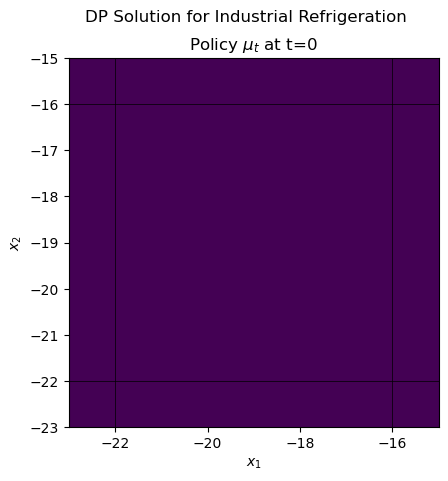

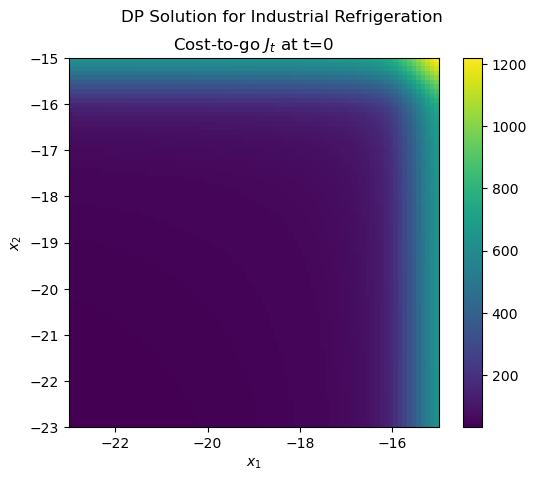

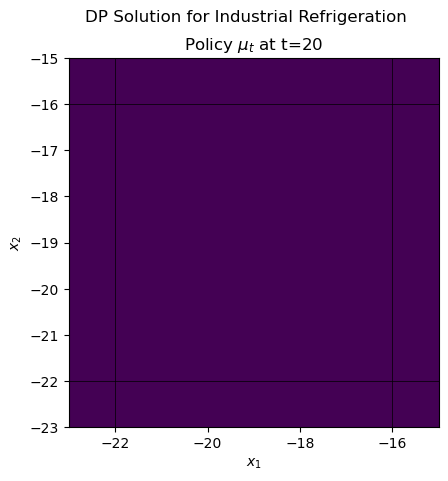

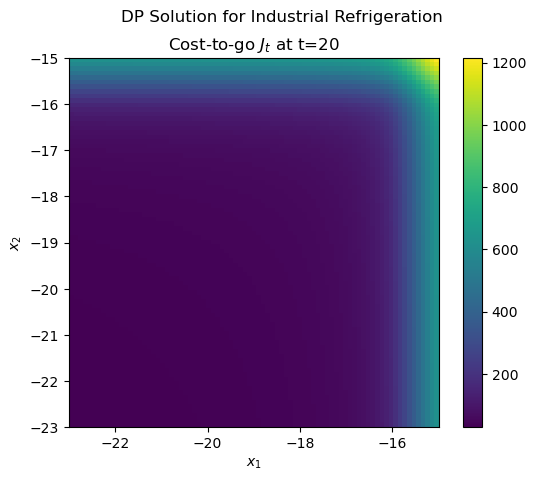

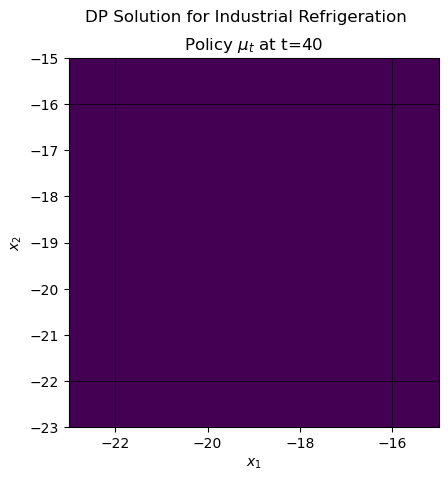

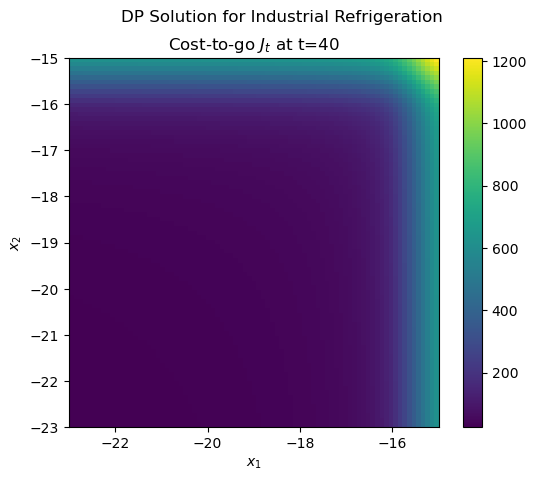

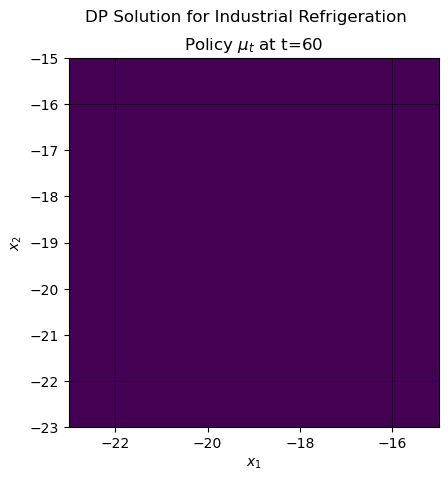

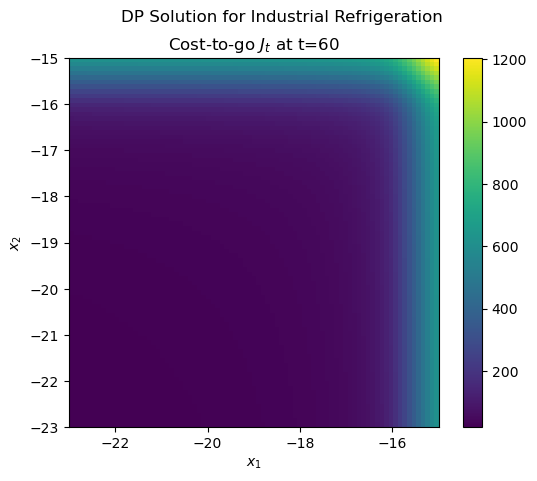

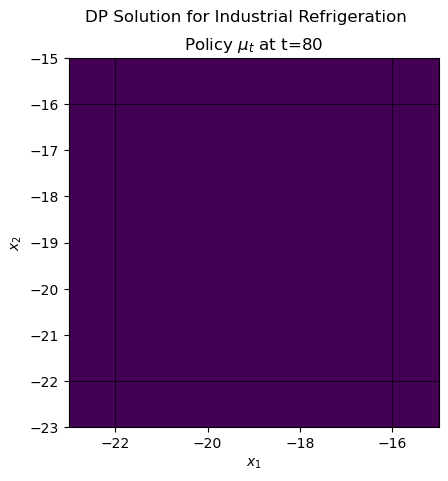

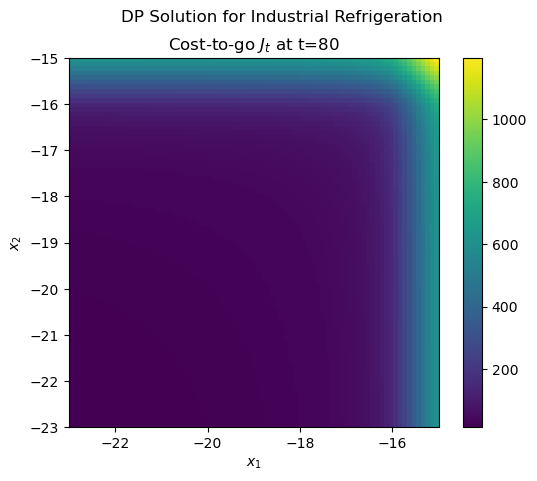

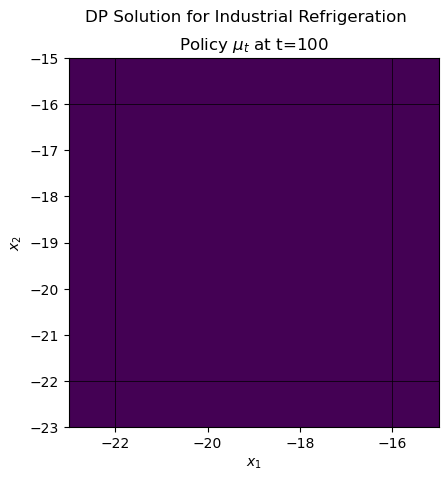

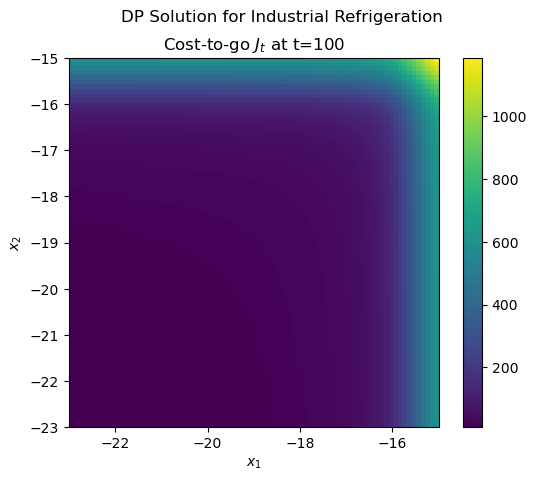

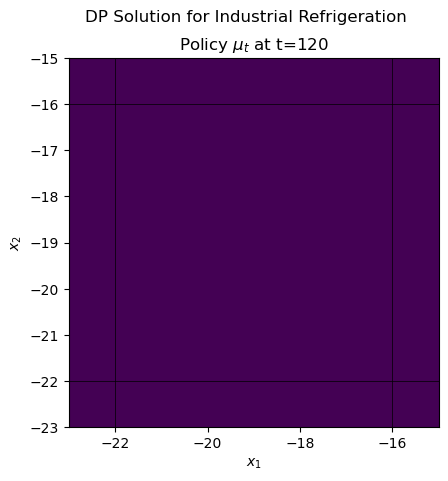

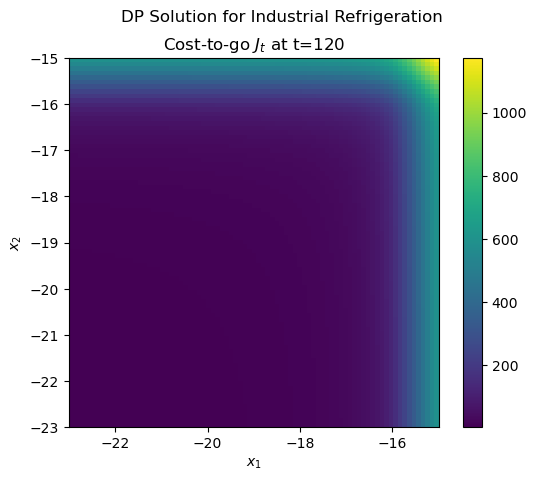

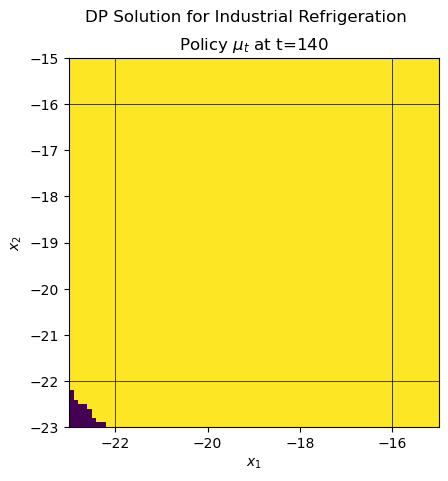

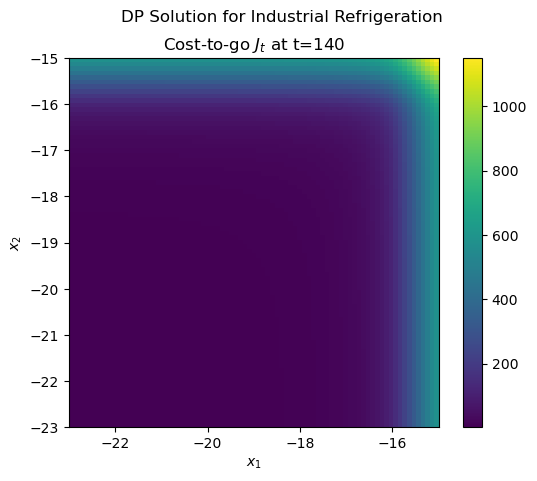

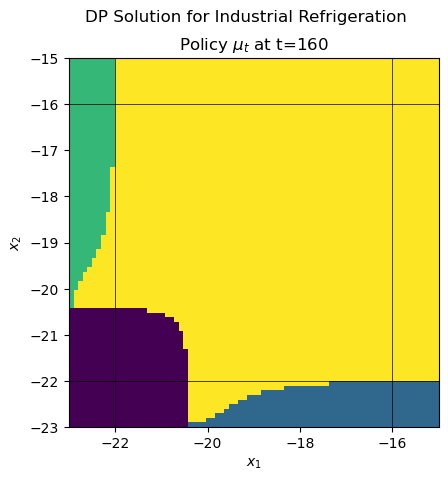

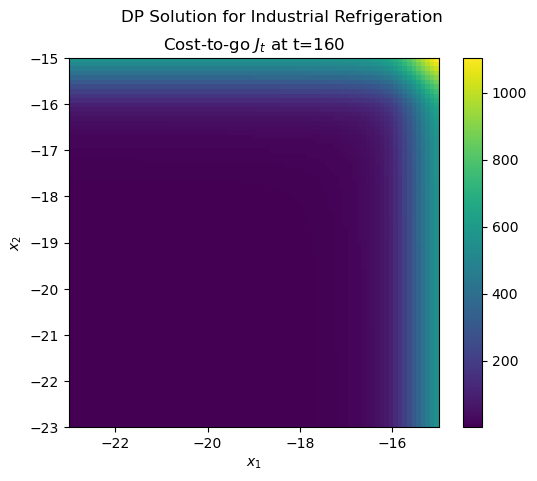

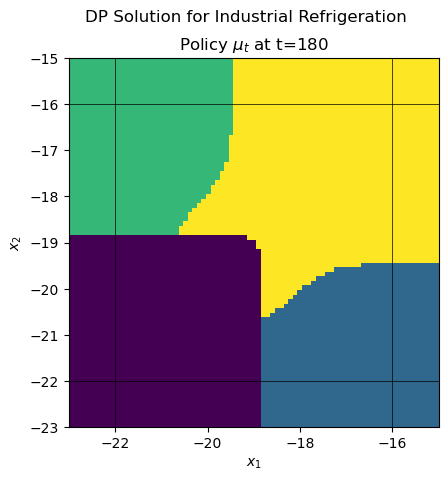

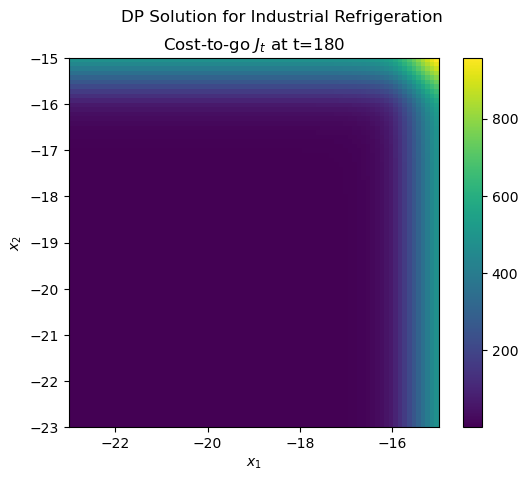

In [28]:
visualize(x_vec, ACTIONS, J, U, dk=20, suptitle="DP Solution for Industrial Refrigeration")

In [53]:
N = 100                  # finite horizon length
dt = 60.0                # time step [s]
num_rooms = 2
b = 2.29e4 * np.ones(num_rooms)          # evap constants [W/K]
c_room = 4.05e7                           # room specific heat [J/K]
gamma = 0.99                                # discount factor
dx = 0.1                                   # state discretization
x_left, x_right = -24.0, -14.0             # state space limits
x_lims = np.array([-22.0, -16.0])          # violation thresholds
violation_costs = np.array([0.0, 1])     # [low_side, high_side] per-K penalty
T_suction = -27.0                          # suction temperature [C]
w_left, w_right = 0.0, 300000               # disturbance limits [W]
u_vec = np.array([0, 1], dtype=np.int64)   # control options per room
elec_cost = 1e-8                           # price of electricity
dk = 10                                    # plotting frequency (if you add plots)


In [59]:
# -----------------------------
# DP containers
# -----------------------------
J = [None] * N
U = [None] * (N - 1)  # greedy action indices 0..3 per (x1,x2)

# Terminal cost
J[-1] = state_cost(X, x_lims, violation_costs, dt)  # shape (nx, nx)

# Prebuild (nx, nx, K) disturbances for broadcasting
# (each “slice” k uses W1_vals/W2_vals[k] for both rooms)
X1_exp = np.repeat(X1[..., None], K, axis=2)  # (nx, nx, K)
X2_exp = np.repeat(X2[..., None], K, axis=2)  # (nx, nx, K)
W1_flat = W1_vals.ravel()                     # (K,)
W2_flat = W2_vals.ravel()                     # (K,)

# -----------------------------
# Backward DP
# -----------------------------
for k in range(N - 2, -1, -1):
    # Interpolator for J_{k+1}
    interp = RegularGridInterpolator((x_vec, x_vec), J[k + 1], bounds_error=False, fill_value=None)

    J_u = np.empty((nx, nx, nA), dtype=np.float64)

    for ai, (u1, u2) in enumerate(ACTIONS):
        # Evaporator cooling under action (u1,u2)
        Q1, Q2 = evap_cooling(u1, u2, b[0], b[1], X1, X2, T_suction, Q_max)
        Qtot = Q1 + Q2  # (nx, nx)

        # Next state for each disturbance atom (vectorized over K)
        # X_next = X + (dt/c_room) * (W - Q_evap)
        X1_next = X1_exp + (dt / c_room) * (W1_flat[None, None, :] - Q1[..., None])
        X2_next = X2_exp + (dt / c_room) * (W2_flat[None, None, :] - Q2[..., None])

        # Clip to state bounds
        np.clip(X1_next, x_left, x_right, out=X1_next)
        np.clip(X2_next, x_left, x_right, out=X2_next)

        # Interpolate J_{k+1} at next states (nx*nx*K, 2) → (nx*nx*K,)
        pts = np.stack([X1_next.ravel(), X2_next.ravel()], axis=-1)
        J_next = interp(pts).reshape(nx, nx, K)  # (nx, nx, K)

        # Expected value over disturbances
        # (weighted dot over last axis)
        J_next_ev = np.tensordot(J_next, W_probs_vec, axes=([2], [0]))  # (nx, nx)

        # Bellman: stage cost + gamma * expected next
        stage_state = state_cost(X, x_lims, violation_costs, dt)                           # (nx, nx)
        stage_action = action_cost(Qtot, Q_max, W_max, elec_cost, dt)              # (nx, nx)
        J_u[..., ai] = stage_state + stage_action + gamma * J_next_ev

    # Greedy selection over actions
    J[k] = np.min(J_u, axis=2)
    U[k] = np.argmin(J_u, axis=2).astype(np.int64)   # 0..3 corresponds to ACTIONS rows

    # (Optional) simple progress print
    # if (N - 1 - k) % 10 == 0: print(f"DP progress: t={k}, remaining sweeps={k}")

# -----------------------------
# Results
# -----------------------------
# J[0] is the optimal cost-to-go at t=0 for each (x1,x2) grid point
# U[k] is the greedy action index at time k for each grid point (x1,x2)
# To decode U[k] to (u1,u2): ACTIONS[U[k][i,j]]

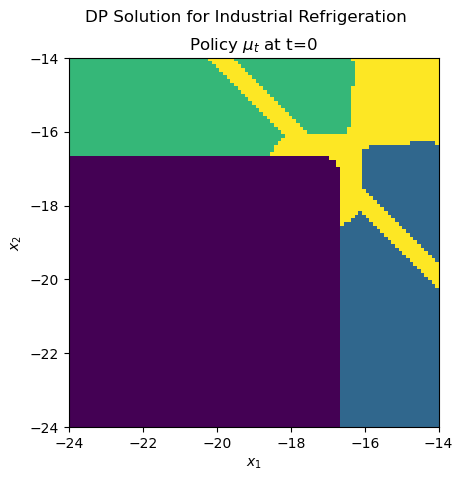

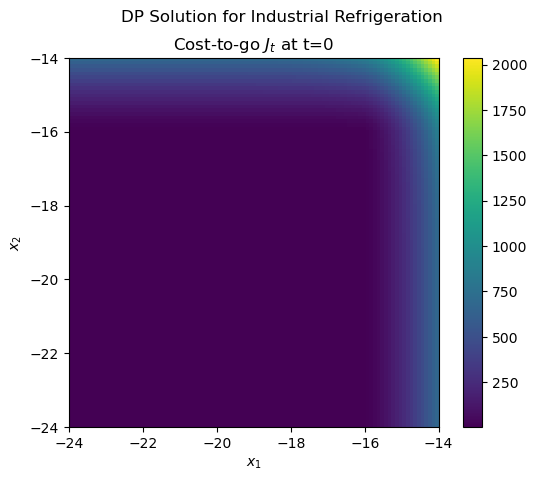

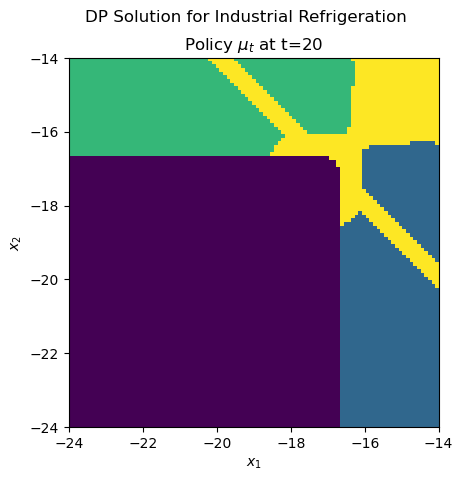

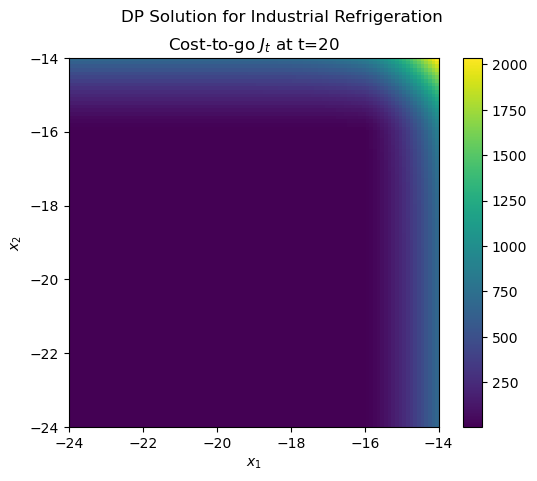

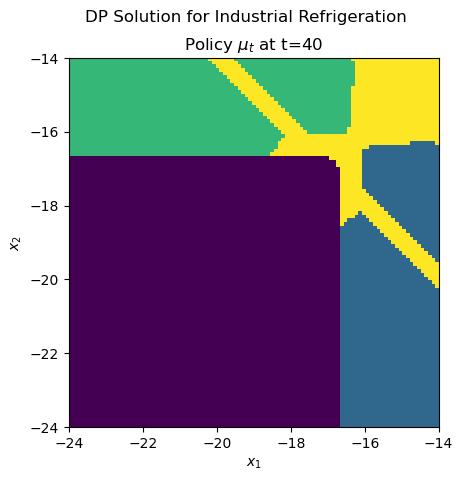

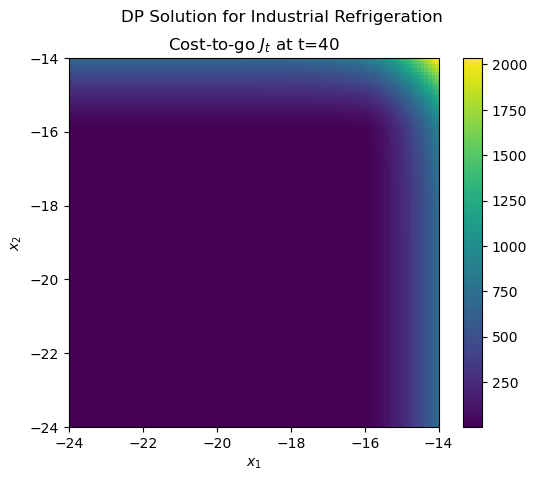

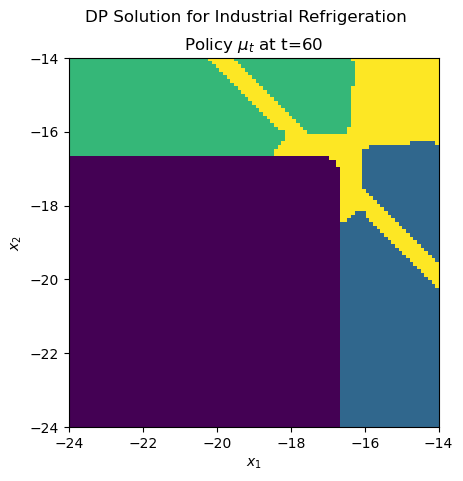

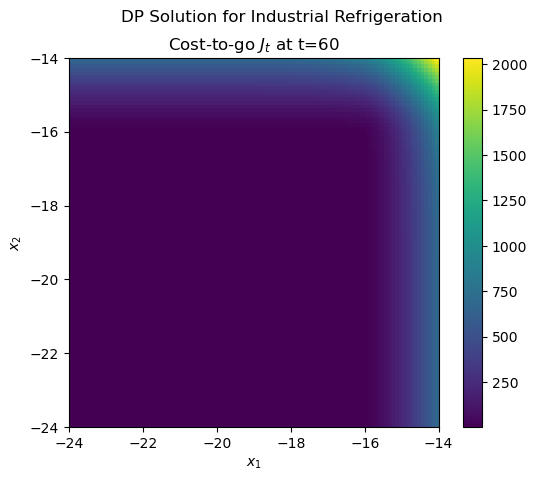

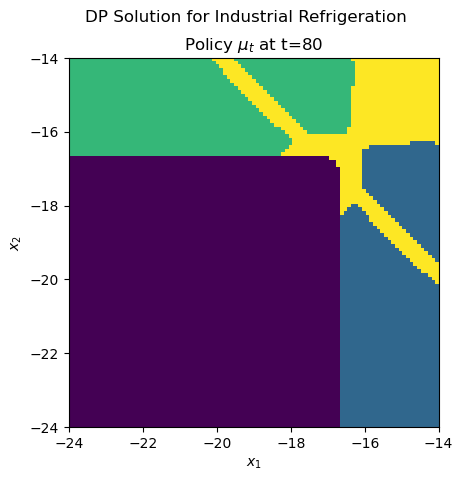

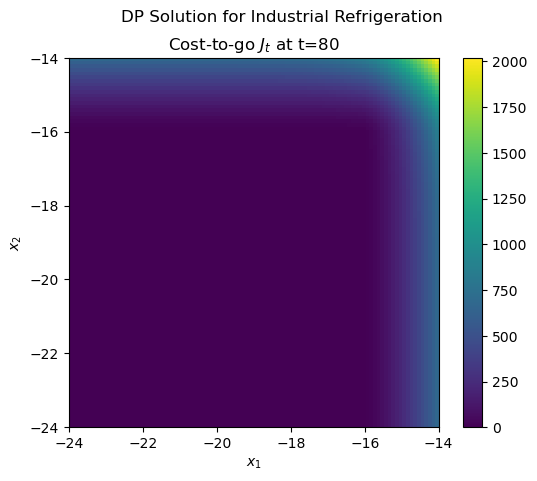

In [60]:
visualize(x_vec, ACTIONS, J, U, dk=20, suptitle="DP Solution for Industrial Refrigeration")